## Lab11: Preprocesamiento de Datos para Machine Learning

**Objetivo:** Aplicar las principales técnicas de prepocesamiento de datos para preparar un DataSet antes de entrenar un modelo de ML. 

**Problema:** Se desea construir un modelo capaz de predecir si un pasajero sobrevivió o no al hundimiento del Titanic. 

In [99]:
#Importamos librerias 
import pandas as pd 
import numpy as np 

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import accuracy_score 

import seaborn as sns 
import matplotlib.pyplot as plt 

In [100]:
import kagglehub

In [101]:
path = kagglehub.dataset_download("yasserh/titanic-dataset")

In [102]:
print("Ruta del dataset:", path)

Ruta del dataset: C:\Users\penar\.cache\kagglehub\datasets\yasserh\titanic-dataset\versions\1


In [103]:
dfTitanic = pd.read_csv(path + "/Titanic-Dataset.csv")

## Parte 1. Comprension del problema 
1. Determinar si sobreviven al hundimiento del titanic, con base en la información obtenida.
2. Survived
   0 - No sobrevivió
   1 - Sobrevivió 

In [104]:
dfTitanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0000,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0000,0,0,373450,8.0500,NaN,S


In [105]:
dfTitanic["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

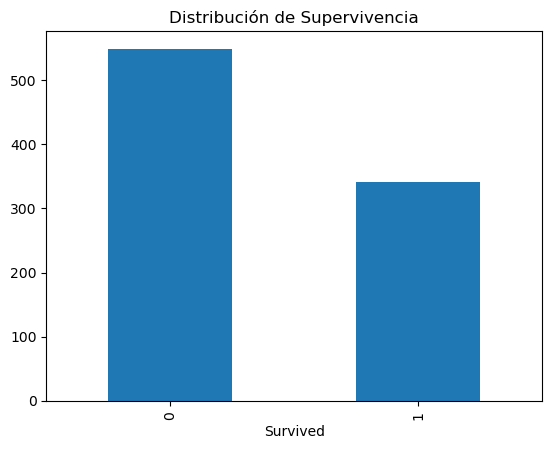

In [106]:
#Graficamos 
dfTitanic["Survived"].value_counts().plot(
    kind="bar"
)
plt.title("Distribución de Supervivencia") 
plt.show()

## Parte 2. Exploración inicial 

In [107]:
dfTitanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.0000,891.0000,891.0000,714.0000,891.0000,891.0000,891.0000
mean,446.0000,0.3838,2.3086,29.6991,0.5230,0.3816,32.2042
std,257.3538,0.4866,0.8361,14.5265,1.1027,0.8061,49.6934
min,1.0000,0.0000,1.0000,0.4200,0.0000,0.0000,0.0000
25%,223.5000,0.0000,2.0000,20.1250,0.0000,0.0000,7.9104
50%,446.0000,0.0000,3.0000,28.0000,0.0000,0.0000,14.4542
75%,668.5000,1.0000,3.0000,38.0000,1.0000,0.0000,31.0000
max,891.0000,1.0000,3.0000,80.0000,8.0000,6.0000,512.3292


In [108]:
#Hipotesis inicial
dfTitanic.groupby(
    "Sex"
)["Survived"].mean()

Sex
female   0.7420
male     0.1889
Name: Survived, dtype: float64

In [109]:
dfTitanic.groupby(
    "Pclass"
)["Survived"].mean()

Pclass
1   0.6296
2   0.4728
3   0.2424
Name: Survived, dtype: float64

In [110]:
dfTitanic.groupby(
    "Fare"
)["Survived"].mean()

Fare
0.0000     0.0667
4.0125     0.0000
5.0000     0.0000
6.2375     0.0000
6.4375     0.0000
            ...  
227.5250   0.7500
247.5208   0.5000
262.3750   1.0000
263.0000   0.5000
512.3292   1.0000
Name: Survived, Length: 248, dtype: float64

## Parte 3. Correlación e Hipótesis 

Creamos una matriz de correlación para identificar la relación lineal entre las variables. NO identifica la importancia real de variables en el modelo

In [111]:
variables_numericas = [
    "Survived",
    "Pclass", 
    "Age",
    "SibSp", 
    "Parch",
    "Fare"
]

In [112]:
corr = dfTitanic[variables_numericas].corr()

In [113]:
corr

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.0000,-0.3385,-0.0772,-0.0353,0.0816,0.2573
Pclass,-0.3385,1.0000,-0.3692,0.0831,0.0184,-0.5495
Age,-0.0772,-0.3692,1.0000,-0.3082,-0.1891,0.0961
SibSp,-0.0353,0.0831,-0.3082,1.0000,0.4148,0.1597
Parch,0.0816,0.0184,-0.1891,0.4148,1.0000,0.2162
Fare,0.2573,-0.5495,0.0961,0.1597,0.2162,1.0000


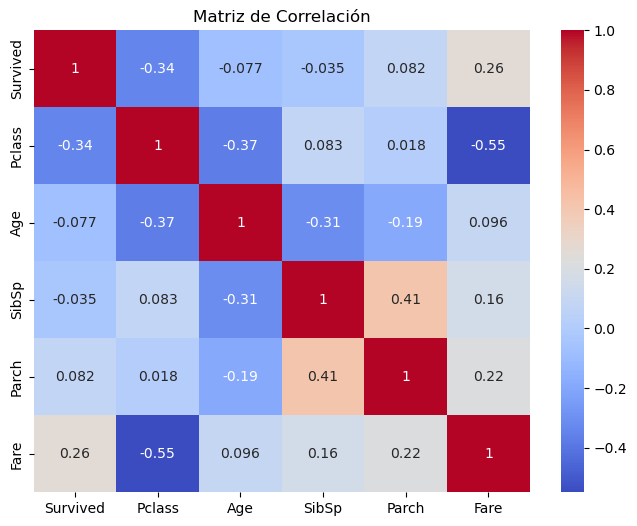

In [114]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
    )
plt.title("Matriz de Correlación")
plt.show()

# Parte 4. Selecciona de variables Predictoras y Variable objetivo 

X- Variables que utlizará el modelo 
Y - Variable que queremos predecir 

In [115]:
columnas = [
    "Pclass", 
    "Sex", 
    "Age", 
    "SibSp", 
    "Parch", 
    "Fare", 
    "Embarked"
]

In [116]:
#Definimos x y 
X = dfTitanic[columnas]
y = dfTitanic["Survived"] 

In [117]:
print(X.columns.tolist())

['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [118]:
print(y.name)

Survived


## Parte 5. Tratamiento de los valores 
Para simplificar el proceso, realizaremos la imputación de los datos antes de la separación TRAIN/TEST

In [119]:
#Revisamos las variables predictoras
X.isnull().sum()

Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [120]:
X["Age"] = X["Age"].fillna(
    X["Age"].median()
)

C:\Users\penar\AppData\Local\Temp\ipykernel_19608\2953535474.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Age"] = X["Age"].fillna(


In [121]:
X["Embarked"] = X["Embarked"].fillna(
    X["Embarked"].mode()[0]
)

C:\Users\penar\AppData\Local\Temp\ipykernel_19608\3303780736.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Embarked"] = X["Embarked"].fillna(


In [122]:
X.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [123]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0000,1,0,7.2500,S
1,1,female,38.0000,1,0,71.2833,C
2,3,female,26.0000,0,0,7.9250,S
3,1,female,35.0000,1,0,53.1000,S
4,3,male,35.0000,0,0,8.0500,S


## Parte 6. Escalar de texto a numérico 
Los algoritmos no entienden texto. Se deben convertir las variables categóricas en variables numéricas.

In [124]:
X = pd.get_dummies(
    X,
    columns=["Sex","Embarked"],
    drop_first=True
)

## Parte 7. Particionamos los datos 

No debemos entrenar y evaluar utilizando los mismos datos. 

La recomendación es: 
Entrenamiento 80% Pruebas 20%

In [125]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20, 
    random_state=42
)

In [126]:
print ("Entrenamiento:", X_train.shape)

Entrenamiento: (712, 8)


In [127]:
print ("Prueba:", y_test.shape)

Prueba: (179,)


In [128]:
variables_numericas

['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

## Parte 8. Escalado de Variables 

Las variables numericas tienen valores distintos. El escalado evita que una variable domine más que otra. 

In [129]:
columnas_numericas = [
    "Age", 
    "Fare", 
    "SibSp", 
    "Parch",
]

In [130]:
X_train[columnas_numericas].describe()

,Age,Fare,SibSp,Parch
count,712.0000,712.0000,712.0000,712.0000
mean,29.2041,32.5863,0.5534,0.3792
std,13.0080,51.9695,1.1764,0.7917
min,0.4200,0.0000,0.0000,0.0000
25%,22.0000,7.9250,0.0000,0.0000
50%,28.0000,14.4542,0.0000,0.0000
75%,35.0000,30.5000,1.0000,0.0000
max,80.0000,512.3292,8.0000,6.0000


In [131]:
scaler = StandardScaler() 
X_train[columnas_numericas] = scaler.fit_transform(
    X_train[columnas_numericas]
)

X_test[columnas_numericas] = scaler.transform(
    X_test[columnas_numericas]
)

In [132]:
pd.set_option('display.float_format', lambda x: '%.4f' % x)
X_train[columnas_numericas].describe()

,Age,Fare,SibSp,Parch
count,712.0000,712.0000,712.0000,712.0000
mean,0.0000,0.0000,0.0000,0.0000
std,1.0007,1.0007,1.0007,1.0007
min,-2.2144,-0.6275,-0.4707,-0.4793
25%,-0.5542,-0.4749,-0.4707,-0.4793
50%,-0.0926,-0.3491,-0.4707,-0.4793
75%,0.4459,-0.0402,0.3799,-0.4793
max,3.9077,9.2377,6.3344,7.1049


In [133]:
pd.set_option('display.float_format', lambda x: '%.4f' % x)
X_test[columnas_numericas].describe()

,Age,Fare,SibSp,Parch
count,179.0000,179.0000,179.0000,179.0000
mean,0.0603,-0.0366,-0.1286,0.0150
std,1.0065,0.7596,0.6216,1.0911
min,-2.1828,-0.6275,-0.4707,-0.4793
25%,-0.5542,-0.4754,-0.4707,-0.4793
50%,-0.0926,-0.3483,-0.4707,-0.4793
75%,0.5228,-0.0034,0.3799,-0.4793
max,3.2154,4.4247,2.9319,5.8409


## Parte 9. Entrenamiento delos datos

Usaremos un arbol de decision para clasificar registros

In [134]:
modelo = DecisionTreeClassifier (
    max_depth = 4,
    random_state= 42
)

In [135]:
modelo.fit(
    X_train, 
    y_train
)

DecisionTreeClassifier(max_depth=4, random_state=42)

## Parte 10. Evaluamos el modelo 
Realizamos predicciones para evaluar el modelo 

In [136]:
predicciones = modelo.predict(
    X_test
)

In [137]:
pd.DataFrame({
    "Real ": y_test,
    "Prediccion ": predicciones
}).head(15)

,Real,Prediccion
709,1,0
439,0,0
840,0,0
720,1,1
39,1,1
290,1,1
300,1,1
333,0,0
208,1,1
136,1,1


## Parte 11, Evaluación del modelo 
El accuracy determina el porcentaje de preddicciones correctas realizadas por el modelo 

In [138]:
accuracy = accuracy_score(
    y_test, 
    predicciones
)

In [139]:
print( f"Accuracy: {accuracy: .4f}")

Accuracy:  0.7989


|Accuracy | Interpretación|
|---------|---------------|
|50% | Adivina |
|60-70% | Aceptable / Basico |
|70-80% | Bueno |
|80-90% | Muy bueno |
| >90% | Excelente (Posible sobreajuste) |

## Parte 12. Implementación de las variables 
Analizar las varibales más relevantes para el algoritmo, al realizar las predicciones. 

In [142]:
importancias = pd.DataFrame({
    "Variable" : X_train.columns, 
    "Importancia" : modelo.feature_importances_ #Que variable es importante para el modelo 
})

In [144]:
importancias.sort_values(
    by="Importancia", 
    ascending=False
)

,Variable,Importancia
5,Sex_male,0.5796
0,Pclass,0.2005
4,Fare,0.0811
1,Age,0.0789
2,SibSp,0.0461
7,Embarked_S,0.0139
3,Parch,0.0000
6,Embarked_Q,0.0000
